# Markov Chain-Based Degradation Modelling and Machine Learning Health State Classification for Power Transformers Using Dissolved Gas Analysis
---

## Generative AI Disclosure

**Tool used:** Claude (Anthropic), versions Sonnet 4.5, Opus 4.6, and Opus 4.7, accessed via [claude.ai](https://claude.ai) between October 2025 and May 2026.

**How the tool was used:**
- *Code scaffolding:* The structure of the MLE transition matrix estimator (Section 2), the convergence study loop over population size and observation window (Section 2), and the correlated multivariate normal DGA sampler (Section 4) were drafted with the assistant's support and then adapted, tested, and validated by the author.
- *Methodology explanation:* The assistant was used to clarify the mathematics of absorbing Markov chains (fundamental matrix, survival function), and the internal workings of `scikit-learn`'s `LogisticRegression`, `RandomForestClassifier`, `StandardScaler`, and `cross_val_score`.
- *Debugging and refactoring:* When code failed or produced unexpected output, the assistant was consulted for diagnosis and refactoring suggestions.
- *Comment generation:* The explanatory comments in this notebook were generated with assistant support and then reviewed for accuracy.

**What the assistant did not do:**
- The five-state health schema, transition probability calibration to a 36-year median life, gas concentration parameters derived from IEEE C57.104-2019, and the 7×7 fault-physics correlation matrix were the author's design decisions, informed by the literature reviewed in the report.
- The choice of classifiers, hyperparameters, evaluation metrics, and the 80/20 train-test split were the author's own decisions.
- All interpretation of results, validation against engineering standards, and the written report are the author's own work.

The author has read every line of this notebook, understands what each block does, and has tested the code against expected behaviour. Any errors are the author's own.

In [2]:
# ════════════════════════════════════════════════════════════════════════
# IMPORTS AND ENVIRONMENT SETUP
# ════════════════════════════════════════════════════════════════════════
# seaborn is used only for the heatmap plots in Section 2 (transition
# matrix estimation). All other plotting is done with matplotlib.
%pip install seaborn

# numpy           - numerical arrays and linear algebra (matrix powers,
#                   matrix inverse for the fundamental matrix)
# pandas          - tabular data handling for the population simulation
#                   and the synthetic DGA dataset
# matplotlib.pyplot - all figures
# seaborn         - heatmaps for transition matrix comparison
# GridSpec        - flexible subplot layouts (not heavily used here)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# scikit-learn machine learning classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, label_binarize

# Default figure resolution for inline display. Final figures saved
# explicitly to PNG with their own dpi setting (see plt.savefig calls).
plt.rcParams['figure.dpi'] = 110

---
## Section 1 — Synthetic Population Dataset and Transition Matrix

This section defines the 5-state absorbing Markov chain and simulates a population of transformers ageing year by year. The same simulation function is reused throughout the notebook.

The "transformer population" produced here is a synthetic population, not real transformers. It is used to (a) validate the maximum likelihood estimator in Section 2 and (b) plot the population health state distribution over time.


In [3]:
states = ["Very Good", "Good", "Fair", "Poor", "Very Poor"]
n_states = len(states)

# ────────────────────────────────────────────────────────────────────────
# True transition matrix P
# ────────────────────────────────────────────────────────────────────────
# Each row gives the probability distribution of next-year state given
# the current state. Properties:
#   - upper triangular: degradation is monotonic, no recovery without
#     maintenance (which is not modelled here)
#   - rows sum to 1: valid probability distributions
#   - P[4,4] = 1: "Very Poor" is absorbing (end of life)
# Diagonal probabilities (0.95, 0.92, 0.88, 0.90) are calibrated so the
# median lifetime from Very Good is ~36 years, matching the industry
# expected service life of up to 40 years
P_true = np.array([
    [0.95, 0.035, 0.010, 0.003, 0.002],
    [0.00, 0.92,  0.050, 0.020, 0.010],
    [0.00, 0.00,  0.88,  0.080, 0.040],
    [0.00, 0.00,  0.00,  0.90,  0.100],
    [0.00, 0.00,  0.00,  0.00,  1.000],
])

# ────────────────────────────────────────────────────────────────────────
# Synthetic dataset generation function
# ────────────────────────────────────────────────────────────────────────
# Simulates a population of transformers, each starting in Very Good and
# transitioning year by year using inverse transform sampling
#
# Inputs:
#   n_transformers - size of the simulated population
#   n_years        - simulation horizon (years per transformer)
#   P              - 5x5 transition matrix to use
#   states         - list of state names
#   seed           - random seed (so simulations are reproducible)
#
# Output: long-format DataFrame with one row per (transformer, year),
# columns: Transformer ID, Year, State (int 0-4), State Name (str)
def generate_dataset(n_transformers, n_years, P, states, seed = 67):
    np.random.seed(seed)        # reproducibility - same seed -> same result
    records = []                # list of [t_id, year, state, state_name] rows

    # Loop over each transformer in the population (1-indexed for readability
    # in printed output)
    for t_id in range(1, n_transformers + 1):
        state = 0               # every transformer begins in state 0 (Very Good)

        # Year-by-year evolution of THIS transformer's health state
        for year in range(1, n_years + 1):
            records.append([t_id, year, state, states[state]])

            # np.random.choice draws ONE next state from the probability
            # distribution given by row `state` of P. The Markov property
            # is enforced here: the next state depends ONLY on the current
            # state, not the history.
            state = np.random.choice(n_states, p = P[state])

    return pd.DataFrame(records, columns = ["Transformer", "Year", "State", "State Name"])

# Generate the canonical dataset used in Sections 1, 2, 3:
# 100 transformers, 80 years each = 8000 (transformer, year) records
df = generate_dataset(100, 80, P_true, states)
print(f"Dataset shape: {df.shape}")
print(df.head(10).to_string(index=False))


Dataset shape: (8000, 4)
 Transformer  Year  State State Name
           1     1      0  Very Good
           1     2      0  Very Good
           1     3      0  Very Good
           1     4      0  Very Good
           1     5      0  Very Good
           1     6      0  Very Good
           1     7      0  Very Good
           1     8      0  Very Good
           1     9      0  Very Good
           1    10      0  Very Good


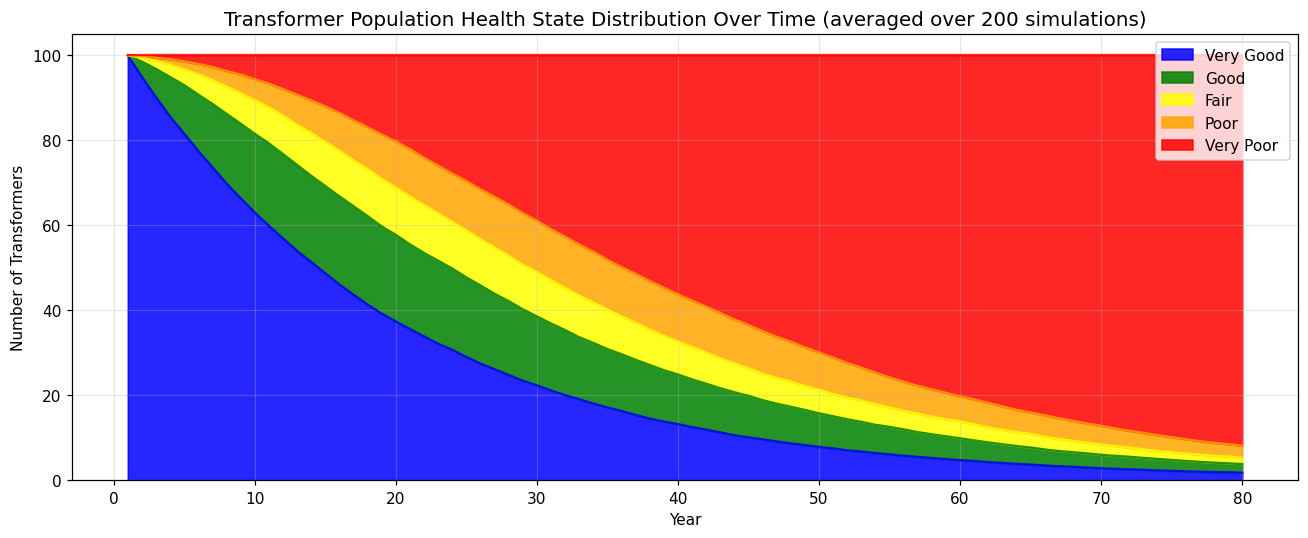

In [7]:
# ════════════════════════════════════════════════════════════════════════
# POPULATION HEALTH STATE DISTRIBUTION OVER TIME 
# ════════════════════════════════════════════════════════════════════════
# The single 100-transformer simulation in cell above is noisy. To get a
# smooth view of the EXPECTED behaviour of the chain, run the simulation
# 200 times with different seeds and average the per-year state counts.
n_simulations = 200
n_transformers = 100
n_years = 80

# avg_counts will hold the running sum of state counts across all sims.
# After the loop, dividing by n_simulations gives the average.
# Shape: (80 years, 5 states)
avg_counts = np.zeros((n_years, n_states))

for sim in range(n_simulations):
    # Each simulation uses a different seed so the populations differ
    df_sim = generate_dataset(n_transformers, n_years, P_true, states, seed = sim)

    # Pivot the long-format DataFrame into a (Year x State) count table.
    # .reindex(columns = states) ensures column order matches the canonical
    # state ordering even if some states are missing in this simulation.
    pivot_sim = (df_sim.groupby(["Year", "State Name"])
                       .size()
                       .unstack(fill_value = 0)
                       .reindex(columns = states))
    avg_counts += pivot_sim.values

# Average across simulations to remove the random sampling noise.
avg_counts /= n_simulations

# Wrap in a DataFrame for matplotlib's stacked area plot
avg_df = pd.DataFrame(avg_counts, index = range(1, n_years + 1), columns = states)

# Colour scheme used consistently throughout the report
# (blue = healthy, red = end of life)
STATE_COLOURS = {
    "Very Good": "blue",
    "Good":      "green",
    "Fair":      "yellow",
    "Poor":      "orange",
    "Very Poor": "red"
}
STATE_COLOURS_LIST = list(STATE_COLOURS.values())

# Stacked area chart - the height of each colour at year t is the average
# number of transformers in that state at year t, across the 200 simulations
fig, ax = plt.subplots(figsize = (12, 5))
avg_df.plot(kind = "area", ax = ax, color = STATE_COLOURS, alpha = 0.85)
ax.set_title("Transformer Population Health State Distribution Over Time (averaged over 200 simulations)", fontsize = 13)
ax.set_xlabel("Year"); ax.set_ylabel("Number of Transformers")
ax.legend(loc = "upper right"); ax.grid(alpha = 0.3)

plt.savefig("figure_4_1_population.png", dpi=300, bbox_inches="tight")
plt.tight_layout(); plt.show()


---
## Section 2 — Transition Matrix Estimation

This section validates the maximum likelihood estimator (MLE) for the transition matrix P. The estimator is run on multiple simulated populations and its output P̂ is compared against the known truth P_true. This proves that, given enough data, the simple counting estimator recovers the true matrix.

The convergence study: confirm that estimator error decreases as either population size or observation window grows.


In [4]:
# ════════════════════════════════════════════════════════════════════════
# MAXIMUM LIKELIHOOD ESTIMATION OF P, AVERAGED OVER 200 SIMULATIONS
# ════════════════════════════════════════════════════════════════════════
# For each simulation:
#   1. Generate a population (different seed each time)
#   2. Count year-on-year state transitions
#   3. Normalise each row to get an estimated transition matrix P̂
# Then average the 200 P̂ matrices to show the estimator is unbiased.
n_simulations = 200
n_transformers = 100
n_years = 80

# Storage for ALL 200 estimated matrices (200, 5, 5)
P_est_all = np.zeros((n_simulations, n_states, n_states))

for sim in range(n_simulations):
    df_sim = generate_dataset(n_transformers, n_years, P_true, states, seed = sim)

    # n_transitions[i,j] counts observed transitions from state i to state j
    n_transitions = np.zeros((n_states, n_states), dtype = int)

    # Group dataset by transformer so each transformer's state sequence is
    # processed separately. groupby returns (key, sub-DataFrame) pairs.
    for t_id, grp in df_sim.groupby("Transformer"):
        # Sort by year so transitions are counted in the correct order
        seq = grp.sort_values("Year")["State"].values
        # Count consecutive (current, next) pairs
        for i in range(len(seq) - 1):
            n_transitions[seq[i], seq[i+1]] += 1

    # Normalise each row to get probabilities (Equation 3.2 in the report).
    # keepdims=True keeps the shape (5,1) so broadcasting works.
    row_sums = n_transitions.sum(axis = 1, keepdims = True)

    # The absorbing state Very Poor never transitions out, so its row sum
    # would be 0 -> divide-by-zero. Replace 0 with 1 so the row stays as
    # all zeros after division (correct behaviour for an absorbing state).
    row_sums = np.where(row_sums == 0, 1, row_sums)
    P_est_all[sim] = n_transitions / row_sums

# Average the 200 estimates element-wise. axis=0 averages across the
# simulation dimension, leaving the (5, 5) shape.
P_est_mean = P_est_all.mean(axis = 0)

# Print mean estimated matrix
print("Mean estimated transition matrix P̂ (averaged over {} simulations):".format(n_simulations))
P_est_mean_df = pd.DataFrame(P_est_mean, index = states, columns = states)
print(P_est_mean_df.round(3).to_string())


Mean estimated transition matrix P̂ (averaged over 200 simulations):
           Very Good   Good   Fair   Poor  Very Poor
Very Good      0.949  0.036  0.010  0.003      0.002
Good           0.000  0.921  0.050  0.020      0.010
Fair           0.000  0.000  0.879  0.080      0.041
Poor           0.000  0.000  0.000  0.898      0.102
Very Poor      0.000  0.000  0.000  0.000      1.000


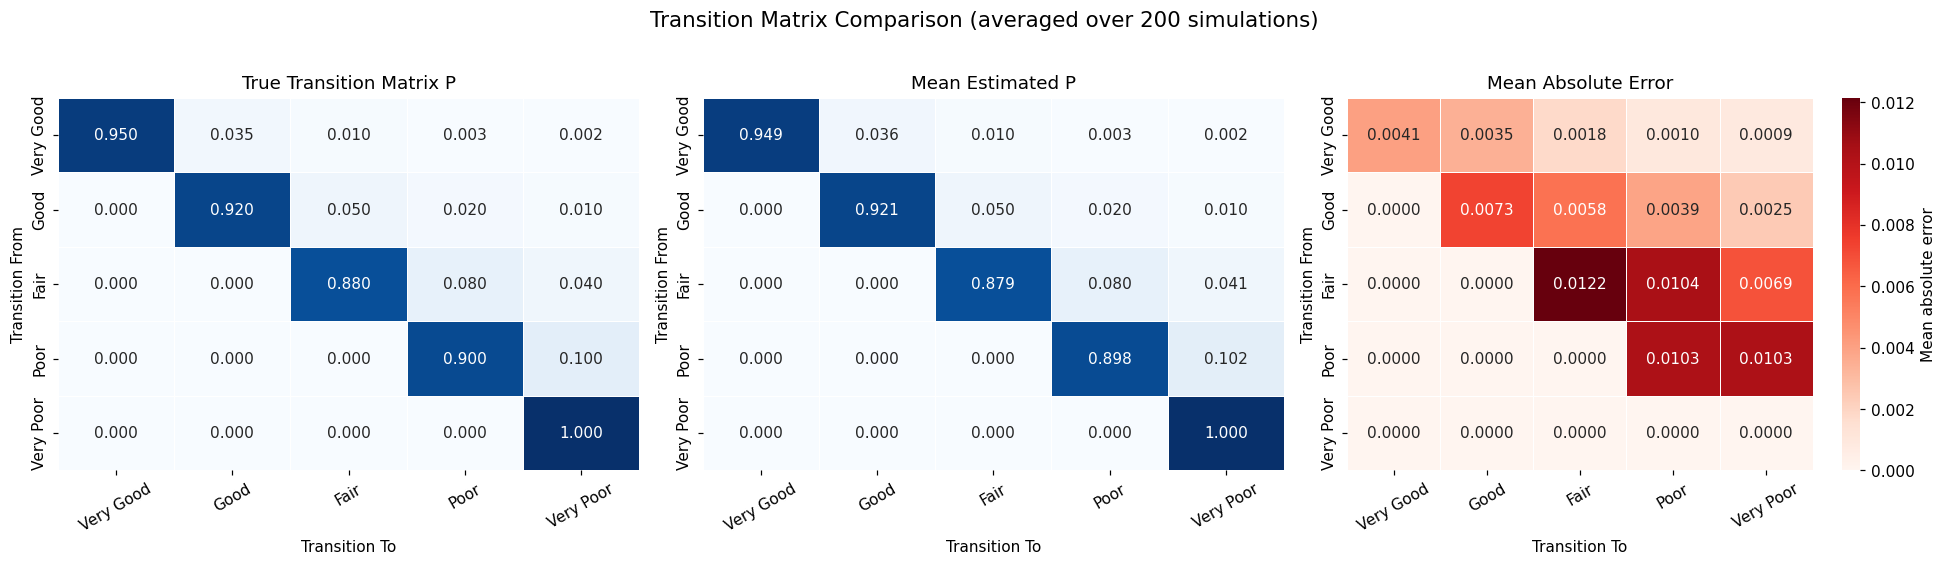


Across 200 simulations of 100 transformers x 80 years:
  Mean absolute error (whole matrix): 0.0032
  Max  absolute error (whole matrix): 0.0122


In [5]:
# ════════════════════════════════════════════════════════════════════════
# HEATMAP COMPARISON: TRUE P vs MEAN ESTIMATED P̂ vs ABSOLUTE ERROR
# ════════════════════════════════════════════════════════════════════════
# abs_err_all[sim, i, j] = |P̂_sim[i,j] - P_true[i,j]|
# The mean over the simulation axis gives the AVERAGE absolute error
# per matrix element (this is the per-element MAE).
abs_err_all = np.abs(P_est_all - P_true)
mean_abs_err = abs_err_all.mean(axis = 0)

# Three heatmaps side by side using a 1x3 subplot grid
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Plot the true matrix and the mean estimate using the same Blues colormap
# so visual comparison is direct. annot=True writes the numerical value
# inside each cell. fmt=".3f" formats as 3 decimal places.
for ax, matrix, title in zip(
    axes[:2],
    [P_true, P_est_mean],
    ["True Transition Matrix P", f"Mean Estimated P"]
):
    sns.heatmap(matrix, annot = True, fmt = ".3f", cmap = "Blues",
                xticklabels = states, yticklabels = states,
                ax = ax, vmin = 0, vmax = 1, linewidths = 0.5, cbar = False)
    ax.set_title(title, fontsize = 12)
    ax.set_xlabel("Transition To"); ax.set_ylabel("Transition From")
    ax.tick_params(axis = "x", rotation = 30)

# Third heatmap: the per-element MAE (Reds colormap to distinguish from
# the matrices). 4 decimal places because errors are small.
sns.heatmap(mean_abs_err, annot = True, fmt = ".4f", cmap = "Reds",
            xticklabels = states, yticklabels = states,
            ax = axes[2], linewidths = 0.5,
            cbar_kws = {"label": "Mean absolute error"})
axes[2].set_title(f"Mean Absolute Error", fontsize = 12)
axes[2].set_xlabel("Transition To"); axes[2].set_ylabel("Transition From")
axes[2].tick_params(axis = "x", rotation = 30)

plt.suptitle("Transition Matrix Comparison (averaged over 200 simulations)", fontsize = 14, y = 1.02)
plt.tight_layout()
plt.savefig("estimated_transition_matrix.png", dpi = 200, bbox_inches = "tight")
plt.show()

# Single-number summary printed below the figure
print(f"\nAcross {n_simulations} simulations of {n_transformers} transformers x {n_years} years:")
print(f"  Mean absolute error (whole matrix): {mean_abs_err.mean():.4f}")
print(f"  Max  absolute error (whole matrix): {mean_abs_err.max():.4f}")


  n =   25 transformers, 80 yrs: MAE = 0.0064 +/- 0.0021
  n =   50 transformers, 80 yrs: MAE = 0.0044 +/- 0.0015
  n =  100 transformers, 80 yrs: MAE = 0.0032 +/- 0.0010
  n =  250 transformers, 80 yrs: MAE = 0.0019 +/- 0.0006
  n =  500 transformers, 80 yrs: MAE = 0.0014 +/- 0.0005
  n = 1000 transformers, 80 yrs: MAE = 0.0010 +/- 0.0003
  100 transformers, 10 yrs: MAE = 0.0138 +/- 0.0074
  100 transformers, 20 yrs: MAE = 0.0064 +/- 0.0023
  100 transformers, 30 yrs: MAE = 0.0047 +/- 0.0017
  100 transformers, 40 yrs: MAE = 0.0039 +/- 0.0010
  100 transformers, 60 yrs: MAE = 0.0033 +/- 0.0012
  100 transformers, 80 yrs: MAE = 0.0032 +/- 0.0010


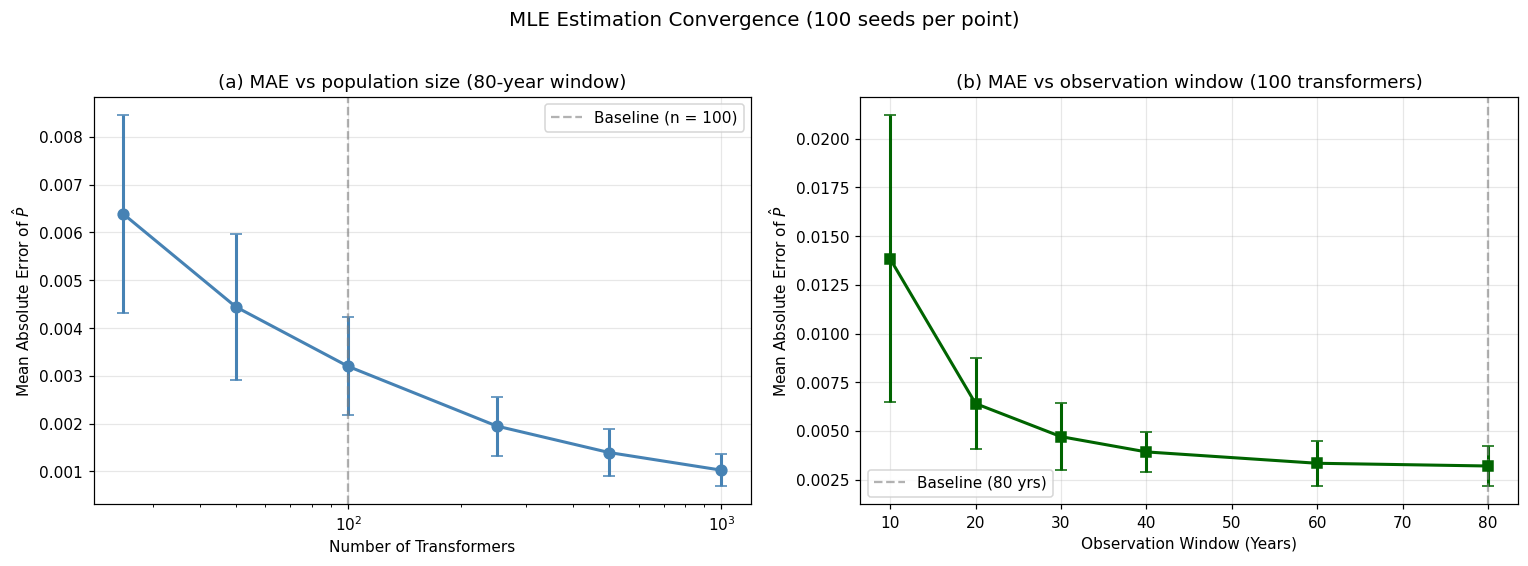

In [5]:
# ════════════════════════════════════════════════════════════════════════
# CONVERGENCE STUDY: MAE vs POPULATION SIZE AND OBSERVATION WINDOW
# ════════════════════════════════════════════════════════════════════════
# This shows the MLE is consistent: doubling population size or window length reduces the average error

def estimate_P_mae(n_transformers, n_years, P_true, n_seeds = 100):
    """Run MLE estimation across multiple seeds, return array of MAE values.

    Same logic as the cell above but condensed and returning per-seed
    error values so we can take both mean (point) and std (error bar).
    """
    errors = np.zeros(n_seeds)
    for seed in range(n_seeds):
        df_sim = generate_dataset(n_transformers, n_years, P_true, states, seed = seed)
        n_transitions = np.zeros((n_states, n_states), dtype = int)
        for t_id, grp in df_sim.groupby("Transformer"):
            seq = grp.sort_values("Year")["State"].values
            for i in range(len(seq) - 1):
                n_transitions[seq[i], seq[i+1]] += 1
        row_sums = n_transitions.sum(axis = 1, keepdims = True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        P_est = n_transitions / row_sums
        errors[seed] = np.abs(P_est - P_true).mean()
    return errors

# ────────────────────────────────────────────────────────────────────────
# Experiment 1: vary population size at fixed 80-year window
# ────────────────────────────────────────────────────────────────────────
# Range chosen to span 1.5 orders of magnitude. Baseline n=100 marked
# on the plot for reference.
pop_sizes = [25, 50, 100, 250, 500, 1000]
pop_means, pop_stds = [], []
for n in pop_sizes:
    errs = estimate_P_mae(n, 80, P_true, n_seeds = 100)
    pop_means.append(errs.mean())
    pop_stds.append(errs.std())
    print(f"  n = {n:4d} transformers, 80 yrs: MAE = {errs.mean():.4f} +/- {errs.std():.4f}")

# ────────────────────────────────────────────────────────────────────────
# Experiment 2: vary observation window at fixed 100-transformer population
# ────────────────────────────────────────────────────────────────────────
# 10 years is too short for many transformers to reach the later states
# so we expect high variance. 80 years is the report baseline.
year_windows = [10, 20, 30, 40, 60, 80]
win_means, win_stds = [], []
for yr in year_windows:
    errs = estimate_P_mae(100, yr, P_true, n_seeds = 100)
    win_means.append(errs.mean())
    win_stds.append(errs.std())
    print(f"  100 transformers, {yr:2d} yrs: MAE = {errs.mean():.4f} +/- {errs.std():.4f}")

# ────────────────────────────────────────────────────────────────────────
# Plot - two side-by-side error-bar plots
# ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# (a) MAE vs population size (log x-axis since we span 25 - 1000)
axes[0].errorbar(pop_sizes, pop_means, yerr = pop_stds,
                 fmt = "o-", capsize = 4, color = "steelblue", lw = 2, markersize = 7)
axes[0].set_xlabel("Number of Transformers")
axes[0].set_ylabel("Mean Absolute Error of $\\hat{P}$")
axes[0].set_title("(a) MAE vs population size (80-year window)")
axes[0].set_xscale("log")
axes[0].grid(alpha = 0.3)
axes[0].axvline(100, color = "grey", linestyle = "--", alpha = 0.6, label = "Baseline (n = 100)")
axes[0].legend()

# (b) MAE vs observation window (linear x-axis - range too narrow for log)
axes[1].errorbar(year_windows, win_means, yerr = win_stds,
                 fmt = "s-", capsize = 4, color = "darkgreen", lw = 2, markersize = 7)
axes[1].set_xlabel("Observation Window (Years)")
axes[1].set_ylabel("Mean Absolute Error of $\\hat{P}$")
axes[1].set_title("(b) MAE vs observation window (100 transformers)")
axes[1].grid(alpha = 0.3)
axes[1].axvline(80, color = "grey", linestyle = "--", alpha = 0.6, label = "Baseline (80 yrs)")
axes[1].legend()

plt.suptitle("MLE Estimation Convergence (100 seeds per point)", fontsize = 13, y = 1.02)
plt.tight_layout()
plt.savefig("convergence_study.png", dpi = 200, bbox_inches = "tight")
plt.show()


---
## Section 3 — Lifetime Modelling

This section computes the analytical lifetime metrics from absorbing-Markov-chain theory: the fundamental matrix N, remaining useful life (RUL) per starting state, and the survival function S(t). 


Fundamental Matrix N  (expected visits to each state):
           Very Good  Good  Fair  Poor
Very Good       20.0   8.7   5.3   6.6
Good             0.0  12.5   5.2   6.7
Fair             0.0   0.0   8.3   6.7
Poor             0.0   0.0   0.0  10.0


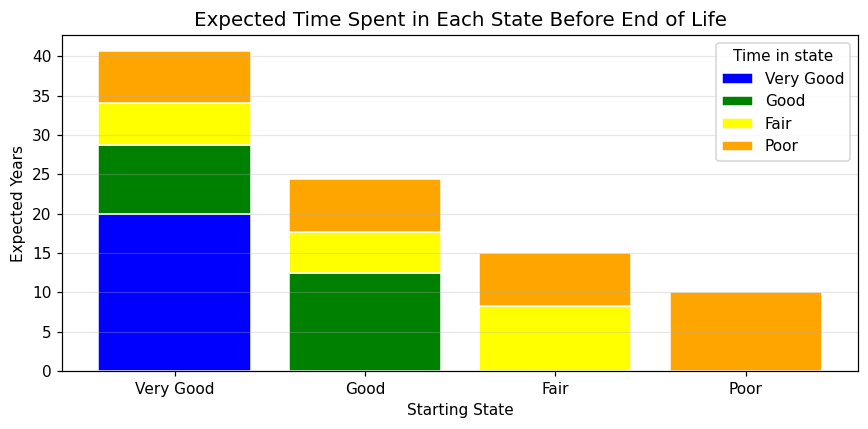

In [8]:
# ════════════════════════════════════════════════════════════════════════
# FUNDAMENTAL MATRIX N AND REMAINING USEFUL LIFE
# ════════════════════════════════════════════════════════════════════════
#   - Write P in canonical form [[Q, R], [0, I]] where Q is the 4x4
#     transition sub-matrix among transient states.
#   - The fundamental matrix N = (I - Q)^-1.
#   - N[i, j] = expected number of years spent in state j when starting
#     in state i, before absorption.
#   - Sum across each row of N gives RUL from that starting state
#     (Equation 3.6).

# Slice out the 4x4 transient-state sub-matrix (rows/cols 0-3, excluding
# Very Poor at index 4)
Q = P_true[:4, :4]

# np.eye(4) is the 4x4 identity matrix; np.linalg.inv computes its
# inverse. (I - Q)^-1 is well-defined because all eigenvalues of Q are
# strictly less than 1 (transient states).
N = np.linalg.inv(np.eye(4) - Q)

# RUL from state i = row sum of N. Equivalently: N @ ones_vector (matrix
# times column of ones). This matches the textbook notation.
RUL = N @ np.ones(4)

# Print the fundamental matrix in a labelled form
N_df = pd.DataFrame(N, index=states[:4], columns=states[:4])
print("Fundamental Matrix N  (expected visits to each state):")
print(N_df.round(1).to_string())

# ────────────────────────────────────────────────────────────────────────
# Stacked bar chart visualisation 
# ────────────────────────────────────────────────────────────────────────
# x-axis: starting state (Very Good - Poor)
# Stack height = total RUL from that starting state
# Each coloured segment shows time spent in each transient state
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(4)            # running stack height
for j, (state_j, color) in enumerate(zip(states[:4], STATE_COLOURS_LIST[:4])):
    vals = N[:, j]              # column j of N = time spent in state j
    ax.bar(states[:4], vals, bottom=bottom, label=state_j, color=color, edgecolor="white")
    bottom += vals              # next stack starts on top of this one

ax.set_title("Expected Time Spent in Each State Before End of Life", fontsize=13)
ax.set_xlabel("Starting State"); ax.set_ylabel("Expected Years")
ax.legend(title="Time in state", bbox_to_anchor=(1, 1)); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("fundamental_matrix.png", dpi = 200, bbox_inches = "tight")
plt.show()

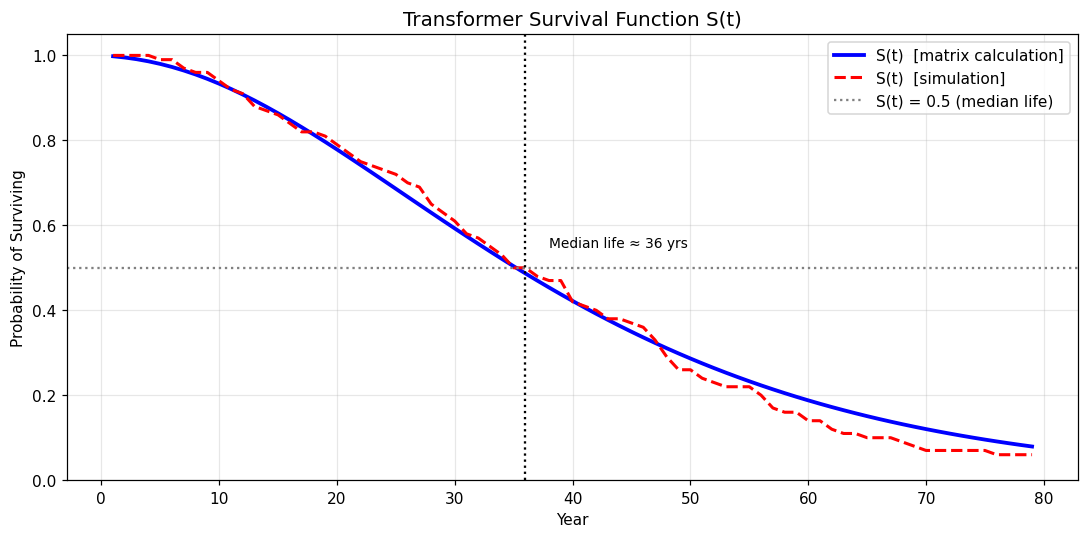

Median transformer lifetime: ~36 years
S(10) = 0.921
S(20) = 0.760
S(30) = 0.574


In [9]:
# ════════════════════════════════════════════════════════════════════════
# SURVIVAL FUNCTION S(t) — analytical and simulated
# ════════════════════════════════════════════════════════════════════════
# Two methods are compared:
#   1) Matrix method:    S(t) = 1 - (H0 @ P^t)[Very Poor]
#   2) Simulation method: count fraction of population not in Very Poor
# They should agree; this validates both approaches.

# ────────────────────────────────────────────────────────────────────────
# Method 1 — analytical via matrix powers
# ────────────────────────────────────────────────────────────────────────
years = np.arange(1, 80)
survival = []
for t in years:
    # P^t = P multiplied by itself t times. matrix_power is the proper
    # numpy function for this (NOT P ** t, which would be element-wise).
    Pt = np.linalg.matrix_power(P_true, t)
    # H0 = initial state distribution. All transformers start Very Good.
    pi0 = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    # pi_t[k] = probability the transformer is in state k at year t
    pit = pi0 @ Pt
    # S(t) = 1 - P(Very Poor at year t). Index 4 is Very Poor.
    survival.append(1 - pit[4])
survival = np.array(survival)

# ────────────────────────────────────────────────────────────────────────
# Method 2 — empirical from the 100-transformer simulation
# ────────────────────────────────────────────────────────────────────────
sim_survival = []
for yr in years:
    # nunique counts distinct transformer IDs that are NOT in Very Poor
    # at year yr. Divide by 100 = total population to get a fraction.
    alive = df[(df["Year"] == yr) & (df["State Name"] != "Very Poor")]["Transformer"].nunique() if yr > 0 else 100
    total = 100
    sim_survival.append(alive / total)
sim_survival = np.array(sim_survival)

fig, ax = plt.subplots(figsize=(10, 5))

# Solid blue = analytical, dashed red = simulation. They should overlap.
ax.plot(years, survival,     color="blue", lw=2.5, label="S(t)  [matrix calculation]")
ax.plot(years, sim_survival, color="red",  lw=2,   ls="--", label="S(t)  [simulation]")
ax.axhline(0.5, ls=":", color="gray", label="S(t) = 0.5 (median life)")

# Find median lifetime: smallest t for which S(t) <= 0.5.
# searchsorted on -survival because survival is decreasing.
t_median = years[np.searchsorted(-survival, -0.5)]
ax.axvline(t_median, ls=":", color="black")
ax.annotate(f"Median life ≈ {t_median} yrs", xy=(t_median, 0.5), xytext=(t_median+2, 0.55), fontsize=9)

ax.set_title("Transformer Survival Function S(t)", fontsize=13)
ax.set_xlabel("Year"); ax.set_ylabel("Probability of Surviving")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("survival_function.png", dpi = 200, bbox_inches = "tight")
plt.show()

# Print summary numbers
print(f"Median transformer lifetime: ~{t_median} years")
print(f"S(10) = {survival[10]:.3f}")
print(f"S(20) = {survival[20]:.3f}")
print(f"S(30) = {survival[30]:.3f}")


---
## Section 4 — Synthetic DGA Sensor Feature Generation

This section generates a 1000-sample synthetic DGA dataset (200 samples per health state, 7 fault gases) used to train and evaluate the classifiers in Section 5. The means and standard deviations come from IEEE C57.104-2019. The 7×7 inter-gas correlation matrix encodes the fault-physics relationships.


In [10]:
# ════════════════════════════════════════════════════════════════════════
# DGA FEATURE GENERATION — GAS CONCENTRATION DISTRIBUTIONS BY STATE
# ════════════════════════════════════════════════════════════════════════
# Seven fault gases (in order):
#   H₂   - hydrogen (PD, arcing)
#   CH₄  - methane  (low-T thermal)
#   C₂H₆ - ethane   (low-T thermal)
#   C₂H₄ - ethylene (high-T thermal)
#   C₂H₂ - acetylene (arcing - key high-energy fault indicator)
#   CO   - carbon monoxide (cellulose degradation)
#   CO₂  - carbon dioxide (cellulose degradation)
FEATURE_NAMES = ["H₂", "CH₄", "C₂H₆", "C₂H₄", "C₂H₂", "CO", "CO₂"]

# ────────────────────────────────────────────────────────────────────────
# Per-state (mean, std) pairs for each of the 7 gases 
# ────────────────────────────────────────────────────────────────────────
# Means derived from IEEE C57.104-2019 thresholds:
#   State 0 (Very Good): ~50% of 90th percentile typical concentrations
#   State 1 (Good):      90th percentile typical
#   State 2 (Fair):      95th percentile typical
#   State 3 (Poor):      midpoint between 95th percentile and pre-failure
#   State 4 (Very Poor): average pre-failure (Bustamante et al. 2020)
# Stds calculated as min((mu_next - mu_current)/4, 0.35*mu_current)
# to produce realistic inter-state overlap without noisy variance
FEATURE_PARAMS = {
    0: [(20, 5),      (10, 2.5),    (7, 2),       (25, 6.25),    (1.0, 0.25),
        (250, 62.5),  (2500, 625)],

    1: [(40, 12.5),   (20, 7),      (15, 5.25),   (50, 12.5),    (2.0, 0.7),
        (500, 25),    (5000, 500)],

    2: [(90, 31.5),   (50, 17.5),   (40, 14),     (100, 35),     (7.0, 2.45),
        (600, 187.5), (7000, 2450)],

    3: [(407.5, 79.38), (225, 43.75), (470, 107.5), (450, 87.5), (228.5, 55.38),
        (1350, 187.5),  (28500, 5375)],

    4: [(725, 253.75), (400, 140),   (900, 315),   (800, 280),   (450, 157.5),
        (2100, 735),   (50000, 17500)],
}

# ────────────────────────────────────────────────────────────────────────
# 7x7 inter-gas correlation matrix 
# ────────────────────────────────────────────────────────────────────────
#   - Thermal gases (CH₄, C₂H₆, C₂H₄): strong positive (0.55-0.70)
#     because thermal faults produce all three together
#   - PD/arcing (H₂, C₂H₂): moderate (0.35-0.50) because high-energy
#     discharges produce H₂ alongside C₂H₂
#   - Cellulose pair (CO, CO₂): strong (0.75) because both come from
#     paper decomposition together
#   - Cross-group (oil x paper): weak (0.05-0.15) because oil and paper
#     degrade by different mechanisms
GAS_CORRELATION = np.array([
   # H₂    CH₄   C₂H₆  C₂H₄  C₂H₂   CO    CO₂
    [1.00, 0.50, 0.30, 0.40, 0.45, 0.15, 0.10],  # H₂
    [0.50, 1.00, 0.70, 0.60, 0.20, 0.10, 0.10],  # CH₄
    [0.30, 0.70, 1.00, 0.55, 0.10, 0.10, 0.10],  # C₂H₆
    [0.40, 0.60, 0.55, 1.00, 0.35, 0.15, 0.10],  # C₂H₄
    [0.45, 0.20, 0.10, 0.35, 1.00, 0.10, 0.05],  # C₂H₂
    [0.15, 0.10, 0.10, 0.15, 0.10, 1.00, 0.75],  # CO
    [0.10, 0.10, 0.10, 0.10, 0.05, 0.75, 1.00],  # CO₂
])

# 15% measurement noise
MEASUREMENT_NOISE = 0.15

# ────────────────────────────────────────────────────────────────────────
# Sampling function — generates n DGA samples for a given health state
# ────────────────────────────────────────────────────────────────────────
def sample_features(state_idx, n = 1, seed = None):
    # Modern numpy RNG (replaces legacy np.random.* calls). seed=None
    # gives a different result each call, seed=int gives reproducible.
    rng = np.random.default_rng(seed)
    params = FEATURE_PARAMS[state_idx]

    # Split (mu, sigma) tuples into two arrays: means[7] and stds[7]
    means = np.array([mu for mu, sigma in params])
    stds  = np.array([sigma for mu, sigma in params])

    # ────────────────────────────────────────────────────────────────────
    # Build covariance matrix from correlation matrix and stds
    # ────────────────────────────────────────────────────────────────────
    # cov[i,j] = corr[i,j] * std_i * std_j
    # np.outer(stds, stds) gives the (std_i * std_j) matrix; element-wise
    # multiplication with the correlation matrix gives covariance.
    cov = GAS_CORRELATION * np.outer(stds, stds)

    # Draw n samples from the multivariate normal distribution N(means, cov)
    # The covariance matrix preserves the correlations between gases so a
    # sample with elevated CH₄ also tends to have elevated C₂H₆ etc.
    samples = rng.multivariate_normal(means, cov, n)

    # ────────────────────────────────────────────────────────────────────
    # Add multiplicative measurement noise (15% of the absolute value)
    # ────────────────────────────────────────────────────────────────────
    # rng.normal(0, 0.15, shape) gives noise fractions; multiplying by
    # |samples| converts these to additive noise scaled to gas magnitude.
    noise = rng.normal(0, MEASUREMENT_NOISE, samples.shape) * np.abs(samples)
    samples = samples + noise

    # Gas concentrations cannot be negative — clip to >= 0
    samples = np.maximum(samples, 0)

    return samples

# ────────────────────────────────────────────────────────────────────────
# Build the labelled dataset: 200 samples per state x 5 states = 1000
# ────────────────────────────────────────────────────────────────────────
N_PER_STATE = 200
X_parts, y_parts = [], []

# Vary the seed per state so each state's 200 samples are independent
for s in range(n_states):
    feats = sample_features(s, N_PER_STATE, seed = 67 + s)
    X_parts.append(feats)                       # (200, 7) for this state
    y_parts.append(np.full(N_PER_STATE, s))     # 200 labels = s

# Stack the per-state matrices into one (1000, 7) feature matrix and
# one length-1000 label vector
X = np.vstack(X_parts)
y = np.concatenate(y_parts)

# Wrap in a DataFrame with named columns for inspection / export
feature_df = pd.DataFrame(X, columns = FEATURE_NAMES)
feature_df["State"] = y
feature_df["State Name"] = feature_df["State"].map(dict(enumerate(states)))


In [11]:
# ════════════════════════════════════════════════════════════════════════
# EXPORT THE 1000-SAMPLE SYNTHETIC DGA DATASET TO CSV
# ════════════════════════════════════════════════════════════════════════
export_df = feature_df.copy()

# Add a 1-indexed Sample ID column at the front for readability
export_df.insert(0, "Sample ID", range(1, len(export_df) + 1))

# Round gas concentrations to 2 dp
for col in FEATURE_NAMES:
    export_df[col] = export_df[col].round(2)

# Reorder columns so the ID and gases come before the labels
export_df = export_df[["Sample ID"] + FEATURE_NAMES + ["State", "State Name"]]

# index=False suppresses the pandas row index column in the output file
export_df.to_csv("synthetic_dga_dataset.csv", index = False)
print(f"Exported {len(export_df)} samples to synthetic_dga_dataset.csv")


Exported 1000 samples to synthetic_dga_dataset.csv


---
## Section 5 — Machine Learning Health State Classification

Two classifiers are trained on the 1000-sample DGA dataset: a multinomial Logistic Regression (linear) and a Random Forest (non-linear ensemble). Both predict one of the five health states from a 7-feature gas reading.

Standard 80/20 train-test split, 5-fold cross-validation on the training set for a stability estimate.


In [12]:
# ════════════════════════════════════════════════════════════════════════
# TRAIN/TEST SPLIT AND FEATURE SCALING
# ════════════════════════════════════════════════════════════════════════
# train_test_split args:
#   test_size=0.2     20% test, 80% training (200 / 800)
#   random_state=67   reproducible split
#   stratify=y        each class (state) appears in train and test in the
#                     same proportions as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 67, stratify = y
)

# Round to whole numbers - real DGA labs report ppm values as integers
X_train = X_train.round(0)
X_test  = X_test.round(0)

# ────────────────────────────────────────────────────────────────────────
# Standardisation - REQUIRED for Logistic Regression
# ────────────────────────────────────────────────────────────────────────
# Why: gas magnitudes span CO₂ (~20,000 ppm) down to C₂H₂ (~10 ppm). A
# linear model would otherwise weight CO₂ too heavily simply because of
# its scale, not its diagnostic importance.
#
# fit_transform on training data:
#   1) compute per-column mean and std from the 800 training samples
#   2) transform: x_scaled = (x - mean) / std
# transform on test data:
#   reuses the TRAINING mean and std (not test set). This is
#   essential to avoid data leakage.
#
# Tree-based models (Random forest) are scale-invariant, so they
# use the raw X_train / X_test directly.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]} DGA gases")


Training set: 800 samples
Test set:     200 samples
Features:     7 DGA gases


In [13]:
# ════════════════════════════════════════════════════════════════════════
# TRAIN BOTH CLASSIFIERS, EVALUATE WITH CROSS-VALIDATION + TEST SET
# ════════════════════════════════════════════════════════════════════════
# Models dictionary - lets us loop over them with the same code
models = {
    # multinomial LR with L2 regularisation (default).
    # C=1.0          inverse regularisation strength (sklearn default)
    # solver="lbfgs" handles multi-class natively
    # max_iter=2000  large enough to guarantee convergence for any C
    "Logistic Regression": LogisticRegression(C = 1.0, solver = "lbfgs", max_iter = 2000, random_state = 67),

    # Random forest hyperparameters chosen to balance accuracy and
    # interpretability without overfitting:
    # n_estimators=50      ensemble of 50 trees
    # max_depth=5          shallow enough to prevent memorisation
    # min_samples_split=5  don't split nodes with fewer than 5 samples
    "Random Forest": RandomForestClassifier(n_estimators = 50, max_depth = 5, min_samples_split = 5, random_state = 67),
}

tuned_results = {}              # store predictions, probabilities, accuracy

for name, clf in models.items():
    print(f"{'-' * 55}")
    print(f"  Training: {name}")

    # Use scaled features for LR, raw for RF (RF doesn't need scaling)
    Xtr = X_train_s if name == "Logistic Regression" else X_train
    Xte = X_test_s  if name == "Logistic Regression" else X_test

    # ────────────────────────────────────────────────────────────────────
    # TRAINING — fit() learns the parameters from the training data
    # ────────────────────────────────────────────────────────────────────
    # LR: finds 5 sets of weights (one per class) that minimise
    #     cross-entropy loss on the 800 training samples.
    # RF: builds 50 decision trees, each on a bootstrap sample of the
    #     training set, splitting on a random subset of features at each
    #     node.
    clf.fit(Xtr, y_train)

    # ────────────────────────────────────────────────────────────────────
    # PREDICTION on the held-out test set
    # ────────────────────────────────────────────────────────────────────
    # predict()       returns the predicted class (0-4) for each sample
    # predict_proba() returns the (200, 5) probability matrix
    y_pred  = clf.predict(Xte)
    y_proba = clf.predict_proba(Xte)

    # ────────────────────────────────────────────────────────────────────
    # CROSS-VALIDATION on the 800 training samples (stability check)
    # ────────────────────────────────────────────────────────────────────
    # Splits the training set into 5 equal folds. For each fold:
    #   - train on the OTHER 4 folds (640 samples)
    #   - score on the held-out fold (160 samples)
    # The 5 accuracies are averaged. Result tells us how stable the model
    # is when the training data changes; should be close to test accuracy
    # if the model is not overfitting.
    cv_acc = cross_val_score(clf, Xtr, y_train, cv = 5, scoring = "accuracy").mean()

    tuned_results[name] = {
        "clf": clf, "y_pred": y_pred, "y_proba": y_proba,
        "cv_acc": cv_acc
    }

    print(f"  CV Accuracy        : {cv_acc:.4f}")
    # Test accuracy = fraction of test samples correctly classified.
    # (y_pred == y_test) gives a length-200 boolean array; .mean() of a
    # boolean array returns the proportion of True values.
    print(f"  Test Accuracy      : {(y_pred == y_test).mean():.4f}")
    print()


-------------------------------------------------------
  Training: Logistic Regression
  CV Accuracy        : 0.9225
  Test Accuracy      : 0.9500

-------------------------------------------------------
  Training: Random Forest
  CV Accuracy        : 0.9650
  Test Accuracy      : 0.9700



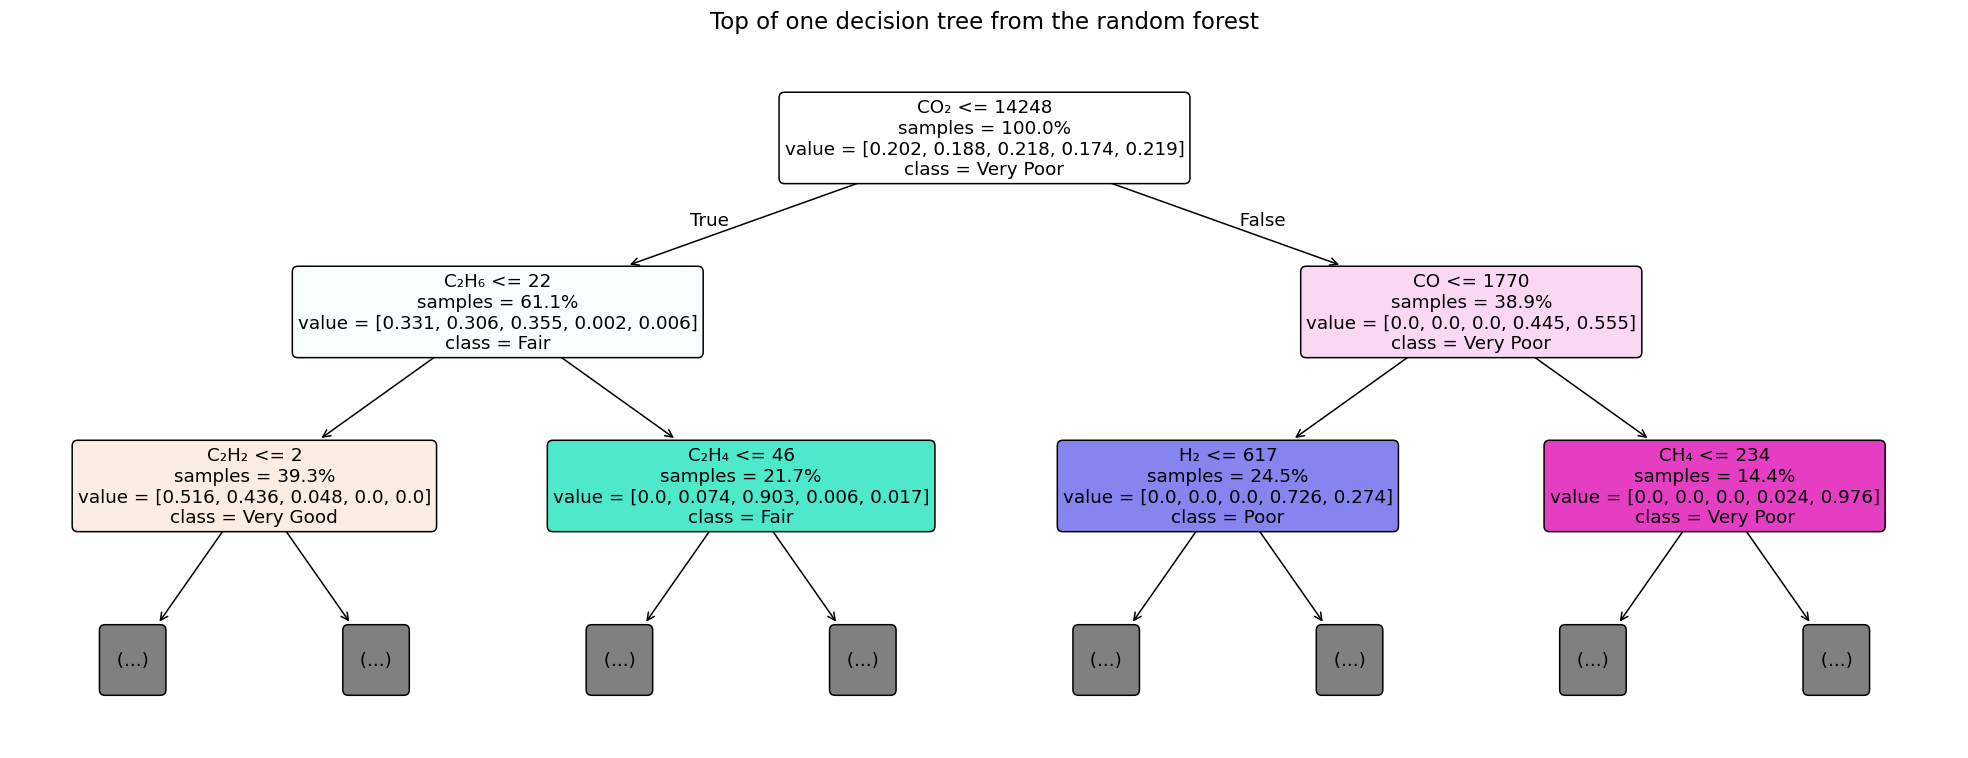

Transformer DGA reading:
  H₂    :        393 ppm
  CH₄   :        128 ppm
  C₂H₆  :        333 ppm
  C₂H₄  :        395 ppm
  C₂H₂  :        221 ppm
  CO    :       1741 ppm
  CO₂   :      25868 ppm

True state:      Poor
Tree prediction: Poor

Decision path:
  Node 0: CO₂ (25868) > 14248  ->  go RIGHT
  Node 8: CO (1741) <= 1770  ->  go LEFT
  Node 9: H₂ (393) <= 617  ->  go LEFT
  Leaf node (102 training samples)
  Probability distribution:
    Very Good : 0.000
    Good      : 0.000
    Fair      : 0.000
    Poor      : 0.859
    Very Poor : 0.141
  -> Predicted class: Poor


In [14]:
# ════════════════════════════════════════════════════════════════════════
# VISUALISE A SINGLE DECISION TREE (Figure 4.8 in the report)
# ════════════════════════════════════════════════════════════════════════
# The production RF uses max_depth=5 which is too deep to show clearly on
# a printed page. So we train a SHALLOW (depth=3) RF just for plotting,
# pull out one of its 50 trees, and render the top 2 levels.
from sklearn.tree import plot_tree
import re                                       # for prettifying threshold values

# Train an explainer-only RF with shallow trees for visualisation
explainer_rf = RandomForestClassifier(n_estimators = 50, max_depth = 3, random_state = 67)
explainer_rf.fit(X_train, y_train)

# Pick the first tree from the ensemble (any tree works; they vote anyway)
the_tree = explainer_rf.estimators_[0]

# ────────────────────────────────────────────────────────────────────────
# Plot the tree with sklearn's plot_tree, then post-process labels
# ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize = (18, 7))
plot_tree(the_tree, feature_names = FEATURE_NAMES, class_names = states,
          filled = True, rounded = True, proportion = True, impurity = False,
          fontsize = 12, ax = ax, max_depth = 2)

# sklearn writes thresholds as decimals like "CO2 <= 14248.5". Round
# these to integers for cleaner visuals (the original ppm readings are
# integers anyway after the .round(0) earlier).
for text_obj in ax.texts:
    txt = text_obj.get_text()

    def round_threshold(match):
        # match.group(1) = "<= ", match.group(2) = the decimal threshold
        return f"{match.group(1)}{int(round(float(match.group(2))))}"

    new_txt = re.sub(r'(<=\s*)(\d+\.\d+)', round_threshold, txt)
    text_obj.set_text(new_txt)

ax.set_title("Top of one decision tree from the random forest", fontsize = 15, pad = 15)
plt.tight_layout()
plt.savefig("rf_tree.png", dpi = 200, bbox_inches = "tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════
# TRACE THE DECISION PATH FOR ONE POOR-CONDITION TEST SAMPLE
# ════════════════════════════════════════════════════════════════════════
# Pick the first test sample whose true label is Poor (state index 3)
poor_idx = np.where(y_test == 3)[0][0]
sample = X_test[poor_idx:poor_idx + 1]               # (1, 7) for sklearn
true_state = states[int(y_test[poor_idx])]
predicted = states[int(the_tree.predict(sample)[0])]

# Print the gas readings of the test sample
print(f"Transformer DGA reading:")
for name, val in zip(FEATURE_NAMES, sample[0]):
    print(f"  {name:<6}: {val:>10.0f} ppm")
print(f"\nTrue state:      {true_state}")
print(f"Tree prediction: {predicted}\n")

# ────────────────────────────────────────────────────────────────────────
# Walk the decision path manually using sklearn's tree internals
# ────────────────────────────────────────────────────────────────────────
tree = the_tree.tree_
# decision_path returns a sparse matrix marking which nodes the sample
# visits on its way from root to leaf.
node_indicator = the_tree.decision_path(sample)
leaf_id = the_tree.apply(sample)[0]                  # final leaf node id
# Pull out the actual sequence of node ids visited
node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

print("Decision path:")
for node_id in node_index:
    if leaf_id == node_id:
        # We've arrived at the leaf - show the class probability vector
        leaf_value = tree.value[node_id][0]
        leaf_probs = leaf_value / leaf_value.sum()       # normalise to 1
        leaf_n_samples = int(tree.n_node_samples[node_id])
        predicted_class = states[int(leaf_value.argmax())]

        print(f"  Leaf node ({leaf_n_samples} training samples)")
        print(f"  Probability distribution:")
        for state, prob in zip(states, leaf_probs):
            print(f"    {state:<10}: {prob:.3f}")
        print(f"  -> Predicted class: {predicted_class}")
    else:
        # Internal node - show which feature/threshold and which way we go
        feat = tree.feature[node_id]
        thr  = tree.threshold[node_id]
        val  = sample[0, feat]
        direction  = "go LEFT"  if val <= thr else "go RIGHT"
        comparison = "<="        if val <= thr else ">"
        print(f"  Node {node_id}: {FEATURE_NAMES[feat]} ({val:.0f}) {comparison} {thr:.0f}  ->  {direction}")


In [15]:
# ════════════════════════════════════════════════════════════════════════
# COMPARE SHALLOW SINGLE TREE vs FULL RANDOM FOREST
# ════════════════════════════════════════════════════════════════════════
# Demonstrates the value of ensembling: a single shallow tree gives a
# noisy probability estimate, but averaging across 50 trees boosts
# confidence in the dominant class.

# Single tree's probability vector for the same sample
single_tree_proba = the_tree.predict_proba(sample)[0]

# The actual deployed RF (depth=5) from the training cell
production_rf    = tuned_results["Random Forest"]["clf"]
production_proba = production_rf.predict_proba(sample)[0]

# Side-by-side comparison table
print("Single tree (depth 3) vs actual Random Forest (depth 5):")
print(f"{'State':<12} {'Single tree':>14} {'Production RF':>16}")
for state, p_tree, p_forest in zip(states, single_tree_proba, production_proba):
    print(f"  {state:<10} {p_tree:>14.3f} {p_forest:>16.3f}")

# Predicted class is whichever has the highest probability
print(f"\nSingle tree prediction:   {states[int(single_tree_proba.argmax())]}")
print(f"Production RF prediction: {states[int(production_proba.argmax())]}")
print(f"True state:               {true_state}")


Single tree (depth 3) vs actual Random Forest (depth 5):
State           Single tree    Production RF
  Very Good           0.000            0.000
  Good                0.000            0.000
  Fair                0.000            0.000
  Poor                0.859            0.968
  Very Poor           0.141            0.032

Single tree prediction:   Poor
Production RF prediction: Poor
True state:               Poor


In [16]:
# ════════════════════════════════════════════════════════════════════════
# PRINT LOGISTIC REGRESSION COEFFICIENTS 
# ════════════════════════════════════════════════════════════════════════
# After training, sklearn stores:
#   clf.coef_      shape (5, 7) - one weight per (state, gas) pair
#   clf.intercept_ shape (5,)   - one bias per state
# These are the parameters of the linear scoring function
#   z_k = b_k + sum_j w_kj * x_j
lr_clf = tuned_results["Logistic Regression"]["clf"]
print("Logistic Regression learned weights:\n")

# Header row
print(f"{'State':<12} {'b (bias)':>8}  " + "  ".join(f"{g:>8}" for g in FEATURE_NAMES))

# One row per state showing bias + 7 gas weights
for k in range(n_states):
    weights = lr_clf.coef_[k]
    bias    = lr_clf.intercept_[k]
    print(f"{states[k]:<12} {bias:>8.3f}  " + "  ".join(f"{w:>8.3f}" for w in weights))


Logistic Regression learned weights:

State        b (bias)        H₂       CH₄      C₂H₆      C₂H₄      C₂H₂        CO       CO₂
Very Good     -10.375    -3.137    -2.782    -1.070    -3.044    -0.383    -6.144    -3.608
Good           -1.803    -2.369    -2.670    -1.574    -1.676    -1.079     1.469    -0.642
Fair            5.313     1.656     1.633    -0.979     1.228    -2.465     1.182     0.189
Poor            6.335     1.703     1.593     0.980     1.731     1.187     1.613     0.903
Very Poor       0.530     2.147     2.225     2.643     1.761     2.740     1.880     3.158


In [17]:
# ════════════════════════════════════════════════════════════════════════
# PRINT STANDARDISATION PARAMETERS 
# ════════════════════════════════════════════════════════════════════════
# These are the per-gas mean and std the StandardScaler computed from the
# 800 training samples. To use the LR equations on a new gas reading you
# would standardise with: x_std = (x_raw - mean) / std, then plug into
# the equations from the cell above.
FEATURE_NAMES = ['H₂', 'CH₄', 'C₂H₆', 'C₂H₄', 'C₂H₂', 'CO', 'CO₂']

print("Standardisation parameters (computed from 800 training samples):")
print(f"\n{'Gas':<6} {'Mean (ppm)':>15} {'Std (ppm)':>15}")

# scaler.mean_ and scaler.scale_ are the saved parameters from .fit()
for gas, mu, sigma in zip(FEATURE_NAMES, scaler.mean_, scaler.scale_):
    print(f"{gas:<6} {mu:>15.2f} {sigma:>15.2f}")


Standardisation parameters (computed from 800 training samples):

Gas         Mean (ppm)       Std (ppm)
H₂              253.87          300.37
CH₄             137.39          159.63
C₂H₆            282.56          383.55
C₂H₄            286.33          334.78
C₂H₂            131.78          187.72
CO              964.29          796.53
CO₂           18940.99        21013.12


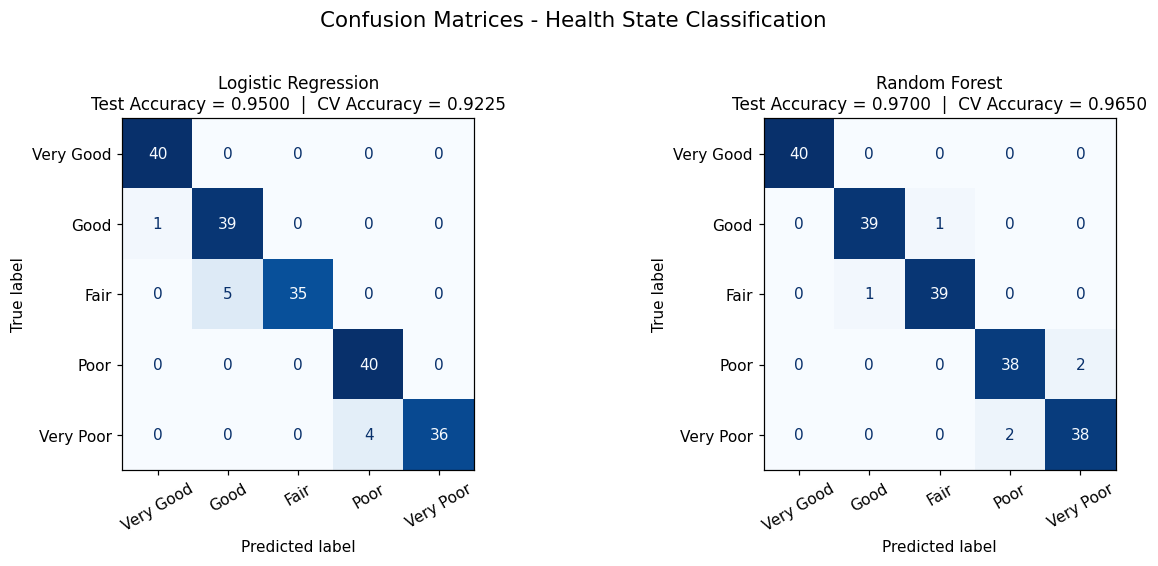

In [18]:
# ════════════════════════════════════════════════════════════════════════
# CONFUSION MATRICES FOR BOTH CLASSIFIERS 
# ════════════════════════════════════════════════════════════════════════
# Each cell C[i, j] of a confusion matrix = number of test samples whose
# TRUE class is i and PREDICTED class is j. The diagonal is correct
# predictions; off-diagonal is errors.
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Loop over both models and plot side-by-side
for ax, (name, res) in zip(axes, tuned_results.items()):
    # Build the confusion matrix from true labels and predictions
    cm = confusion_matrix(y_test, res["y_pred"])

    # ConfusionMatrixDisplay handles axis labels and colour scale
    disp = ConfusionMatrixDisplay(cm, display_labels = states)
    disp.plot(ax = ax, colorbar = False, cmap = "Blues")

    # Title shows both test accuracy and CV accuracy for transparency
    acc = (res["y_pred"] == y_test).mean()
    ax.set_title(
        f"{name}\nTest Accuracy = {acc:.4f}  |  CV Accuracy = {res['cv_acc']:.4f}",
        fontsize = 11
    )
    ax.tick_params(axis = "x", rotation = 30)

plt.suptitle("Confusion Matrices - Health State Classification", fontsize = 14, y = 1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi = 200, bbox_inches = "tight")
plt.show()


---
## Section 6 — Feature Importance

The Random Forest provides a built-in measure of feature importance based on the mean decrease in Gini impurity contributed by each gas across all splits in all 50 trees.

A higher value means splits on that gas resulted in greater reductions in class impurity, making the gas more useful for distinguishing between health states.


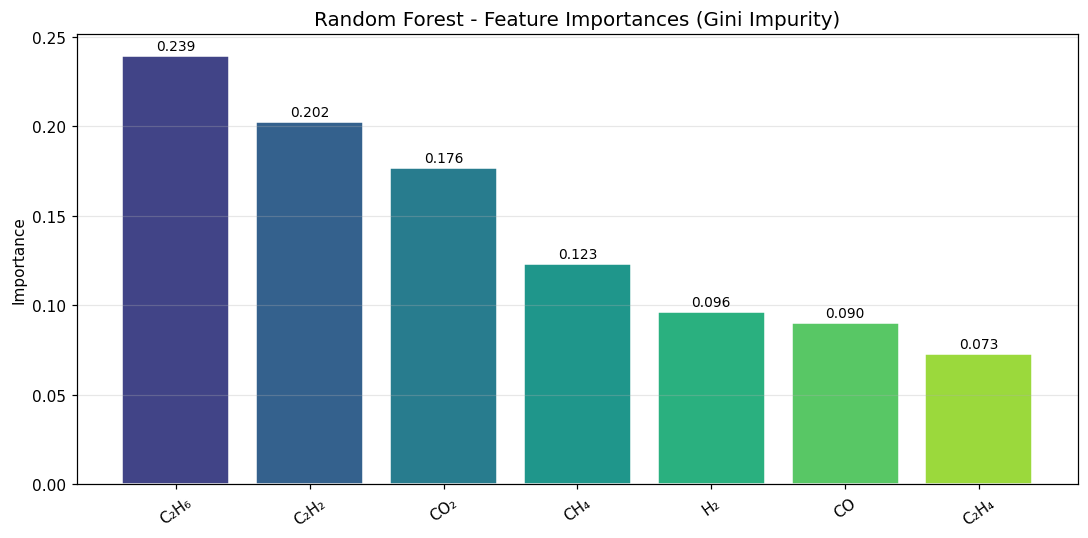

In [19]:
# ════════════════════════════════════════════════════════════════════════
# RANDOM FOREST FEATURE IMPORTANCE 
# ════════════════════════════════════════════════════════════════════════
# Sklearn computes feature_importances_ as the mean (across all 50 trees)
# decrease in Gini impurity contributed by each feature, weighted by the
# number of samples that reach each split. Values sum to 1.
rf_clf      = tuned_results["Random Forest"]["clf"]
importances = rf_clf.feature_importances_

# argsort returns indices that would sort the array in ascending order;
# [::-1] reverses to descending so the most important gas comes first.
sorted_idx = np.argsort(importances)[::-1]

# ────────────────────────────────────────────────────────────────────────
# Feature importance bar chart
# ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize = (10, 5))
bars = ax.bar(
    [FEATURE_NAMES[i] for i in sorted_idx],     # gas names in sorted order
    importances[sorted_idx],                     # ranked in order of importance
    color = [plt.cm.viridis(v) for v in np.linspace(0.2, 0.85, len(FEATURE_NAMES))],
    edgecolor = "white"
)

# Write the importance value on top of each bar
ax.bar_label(bars, fmt = "%.3f", padding = 2, fontsize = 9)

ax.set_title("Random Forest - Feature Importances (Gini Impurity)", fontsize = 13)
ax.set_ylabel("Importance")
ax.tick_params(axis = "x", rotation = 35)
ax.grid(axis = "y", alpha = 0.3)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
